In [111]:
# @launchit.collected

# Begin

In [112]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
import re
import pickle
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
from io import BytesIO
import sqlite3

from tqdm.notebook import tqdm

import lark # @launchit.collect

import numpy as np
from scipy.special import softmax
import cupy as cp
import pandas as pd
import einops
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import torch
import torch.nn.functional as F

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from dataset_utils import *
from utils import * # @launchit.collect
from logging_utils import *
from image_utils import *
import db_utils
import launchit # @launchit.disable
from autoincrement import Autoincrement

# Init

In [113]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    model_group_uri=None,
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'model_group_uri': 'com.develorium.neurovision.15_transformer',
 'subproject_path': '/home/misha/dev/mine/neurovision/15_transformer',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/15_transformer',
 'run_path': '/home/misha/dev/mine/neurovision/run/15_transformer',
 'self_fname': '/home/misha/dev/mine/neurovision/15_transformer/15c_sample_noncasual_01.ipynb',
 'self_name': '15c_sample_noncasual_01',
 'subproject_name': '15_transformer',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [114]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    db_fname: str = None
    top_n: int = None
    batch_size: int = None
    batches_count: int = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42

# Launch

## get_db_con

In [115]:
def get_db_con(hp=None, is_ro=False, autocommit=True):
    hp = LangUtils.coalesce(hp, HP)
    assert hp.db_fname, f'Uninitialized {hp.db_fname=}'
    full_db_fname = os.path.join(CONFIG.private_data_path, hp.db_fname)

    if is_ro:
        return sqlite3.connect(f'file:{full_db_fname}?mode=ro', uri=True, autocommit=autocommit)
    else:
        return sqlite3.connect(full_db_fname, autocommit=autocommit)

## Bootstrap

In [116]:
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

Random seed=42


# Create samples

## Configure

In [117]:
# @launchit.disable
# @launchit.collect
HP.db_fname = 'mini_dataset_5_128.db'
HP.top_n = 3
HP.batch_size = 100
HP.batches_count = None

## Populate

### noncausal_samples & test_noncausal_samples

In [299]:
with get_db_con(autocommit=False) as db_con:
    meta = load_meta(db_con)
    df_vocab_tokens = load_vocab_tokens(db_con)
    
    for is_test in (False, True):
        table_name_prefix = ('', 'test_')[is_test]
        encodings_table_name = table_name_prefix + 'encodings'
        samples_table_name = table_name_prefix + 'noncausal_samples'
        db_utils.drop_table_safe(db_con, samples_table_name)
    
        df_image_inds = pd.read_sql(f'SELECT DISTINCT(image_ind) FROM {encodings_table_name}', con=db_con)
        batches_count = len(df_image_inds) // HP.batch_size + int(bool(len(df_image_inds) % HP.batch_size))
        batches_count = LangUtils.coalesce(HP.batches_count, batches_count)
        rows_count = 0
        reference_sample_len = None
        
        for row_ind, batch_ind in tqdm(zip(range(0, len(df_image_inds), HP.batch_size), range(batches_count)), total=batches_count):
            batch_image_inds = df_image_inds.image_ind.iloc[row_ind:row_ind+HP.batch_size].to_numpy()
            columns = defaultdict(list)
    
            for image_ind in batch_image_inds:
                df_encoding = pd.read_sql(
                    f'SELECT pt.pos_ind, e.vocab_token_ind, vt.vocab_ind, e.logits ' + 
                    f'FROM {encodings_table_name} e, vocab_tokens vt, pos_tokens pt ' +
                    f'WHERE e.pos_token_ind=pt.token_ind AND e.vocab_token_ind=vt.token_ind AND e.image_ind=:image_ind ' +
                    f'ORDER BY pt.pos_ind', 
                    con=db_con, 
                    params=dict(image_ind=int(image_ind))
                )
                assert len(df_encoding) > 0
                reference_sample_len = LangUtils.coalesce(reference_sample_len, len(df_encoding))
                assert len(df_encoding) == reference_sample_len # all noncausal samples must be of equal length
                sample = ','.join((map(str, df_encoding.vocab_token_ind.to_list())))
                columns['image_ind'].append(image_ind)
                columns['sample'].append(sample)

                l_matrix = []
                p_matrix = []
                
                for df_encoding_row in df_encoding.itertuples(index=False):
                    # See dialogs/p_matrix.ipynb for context
                    logits = np.load(BytesIO(df_encoding_row.logits))
                    l_matrix.append(logits)
                    # topk() could be implemented in Numpy using np.argpartition like that:
                    # top_logit_inds_unsorted = np.argpartition(logits, -HP.top_n)[-HP.top_n:]
                    # top_logit_inds_sorted = top_logit_inds_unsorted[np.argsort(logits[top_logit_inds_unsorted])][::-1]
                    top = torch.topk(torch.tensor(logits), HP.top_n + 1)
                    probs = np.zeros_like(logits)

                    method = 2
                    
                    if method == 0:
                        q = (top.values - top.values[-1])[:HP.top_n]
                        probs[top.indices[:HP.top_n]] = q / (q.sum() + 1e-6)
                    elif method == 1:
                        q = -top.values[1:] / top.values[0]
                        probs[top.indices[:HP.top_n]] = torch.softmax(q, 0)
                    elif method == 2:
                        best_mse = top.values[0] + 1e-10 # epsilon for numerical stability
                        ratios = -top.values[:3] / best_mse 
                        probs[top.indices[:HP.top_n]] = torch.softmax(ratios, 0)
                    
                    p_matrix.append(probs)
                    assert np.argmax(probs) == df_encoding_row.vocab_ind

                for matrix_name, matrix in zip(('l_matrix', 'p_matrix'), (l_matrix, p_matrix)):
                    matrix = np.array(matrix)

                    with BytesIO() as b:
                        np.save(b, matrix)
                        columns[matrix_name].append(b.getvalue())
                    
            df = pd.DataFrame(columns)
            df.index += db_utils.get_max_value(db_con, samples_table_name, 'sample_ind') if db_utils.is_table_exists(db_con, samples_table_name) else 0
            df.to_sql(samples_table_name, con=db_con, if_exists='append', index_label='sample_ind')
            db_con.commit()
            rows_count += len(df)
    
        LOG(f'{HP.db_fname}: table "{samples_table_name}" populated, added {rows_count} rows, total {db_utils.get_rows_count(db_con, samples_table_name)} rows')

        index_name = f'idx_{samples_table_name}_image_ind'
        db_con.execute(f'CREATE INDEX {index_name} ON {samples_table_name}(image_ind)')
        db_con.commit()
        LOG(f'{HP.db_fname}: index "{index_name}" created')

  0%|          | 0/10 [00:00<?, ?it/s]

mini_dataset_5_128.db: table "noncasual_samples" populated, added 1000 rows, total 1000 rows
mini_dataset_5_128.db: index "idx_noncasual_samples_image_ind" created


  0%|          | 0/10 [00:00<?, ?it/s]

mini_dataset_5_128.db: table "test_noncasual_samples" populated, added 1000 rows, total 1000 rows
mini_dataset_5_128.db: index "idx_test_noncasual_samples_image_ind" created


# Verify samples

## verify_samples

In [203]:
def verify_samples(is_test):
    with get_db_con(is_ro=True) as db_con:
        meta = load_meta(db_con)
        df_vocab_tokens = load_vocab_tokens(db_con)
        df_pos_tokens = load_pos_tokens(db_con)
        pos_ind_to_pos_token = dict(map(lambda t: (t.pos_ind, t), df_pos_tokens.itertuples()))
        
        table_name_prefix = ('', 'test_')[is_test]
        samples_table_name = table_name_prefix + 'noncausal_samples'
        df_image_inds = pd.read_sql(f'SELECT DISTINCT(image_ind) FROM {samples_table_name}', con=db_con)
        image_ind = int(RNG.choice(df_image_inds.image_ind))
        # image_ind = 36947
        # image_ind = 16346 # thin 6 which shows poor reconstruction
        df_samples = pd.read_sql(f'SELECT sample ' + 
                                 f'FROM {samples_table_name} ' + 
                                 f'WHERE image_ind=?', params=[image_ind], con=db_con)
        sample = next(df_samples.itertuples()).sample
        sample = np.array(list(map(int, sample.split(','))))
        
        fig, axd = plt.subplot_mosaic(
            [
                ['A', 'A', 'A', 'B', 'B', 'B'],
                ['A', 'A', 'A', 'B', 'B', 'B'],
                ['A', 'A', 'A', 'B', 'B', 'B'],
                ['C', 'D', 'E', 'F', 'G', 'H'],
                ['I', 'J', 'K', 'L', 'M', 'N'],
            ], 
            layout="constrained"
        )
        fig.set_figwidth(12)
        fig.set_figheight(8)
        image = load_image(db_con, image_ind, is_test)
        fig.suptitle(f'{LangUtils.when(is_test, "Test Image", "Image")} #{image_ind}')
        im = axd['A'].imshow(image)
        fig.colorbar(im, ax=axd['A'])
        b_image = np.zeros((meta.image_size, meta.image_size))
    
        for ind, vocab_token_ind in enumerate(sample):
            pt = pos_ind_to_pos_token[ind]
            
            df_vocab_token = df_vocab_tokens[df_vocab_tokens.index == vocab_token_ind]
            assert len(df_vocab_token) == 1
            vt = next(df_vocab_token.itertuples())
            with BytesIO(vt.data) as b: vocab_item = np.load(b)
            b_image[pt.i:pt.i2,pt.j:pt.j2] = ArrayUtils.v2sm(vocab_item)
        
        im = axd['B'].imshow(b_image)
        fig.colorbar(im, ax=axd['B'])
        
        random_pos_inds = RNG.choice(len(sample), 12, replace=False)
        
        for ind, (pos_ind, ax_name) in enumerate(zip(random_pos_inds, 'CDEFGHIJKLMN')):
            vocab_token_ind = sample[pos_ind]
            color = 'rgbmy'[ind % 5]

            pt = pos_ind_to_pos_token[pos_ind]
            rect = pltpatches.Rectangle((pt.j-0.5, pt.i-0.5), meta.patch_size, meta.patch_size, linewidth=2, edgecolor=color, facecolor='none')
            axd['A'].add_patch(rect)
            
            df_vocab_token = df_vocab_tokens[df_vocab_tokens.index == vocab_token_ind]
            assert len(df_vocab_token) == 1
            vt = next(df_vocab_token.itertuples())
            with BytesIO(vt.data) as b: vocab_item = np.load(b)
            
            ax = axd[ax_name]
            title = '\n'.join((
                f'{pt.Index}, {vt.Index}',
            ))
            ax.set_title(title, c=color, fontdict=dict(fontsize=10))
            ax.imshow(ArrayUtils.v2sm(vocab_item))
            ax.set_axis_off()

## Verify train

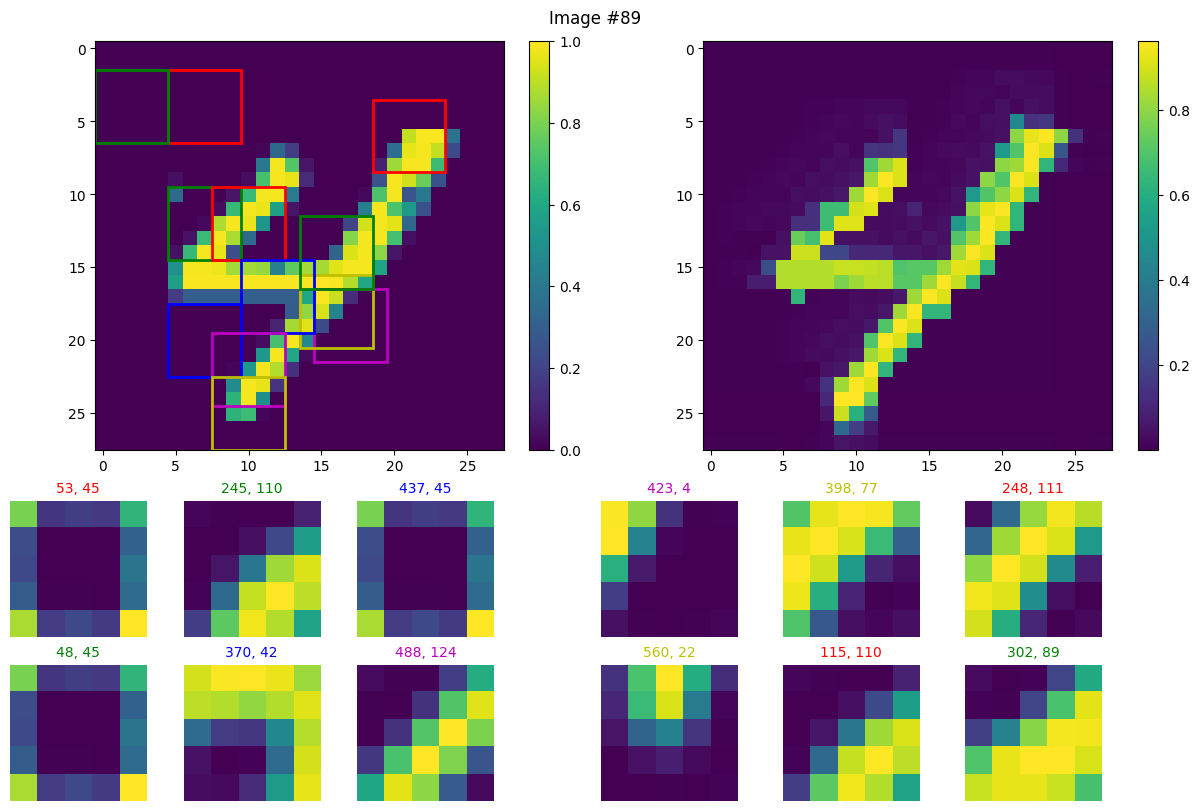

In [204]:
verify_samples(is_test=False)

## Verify test

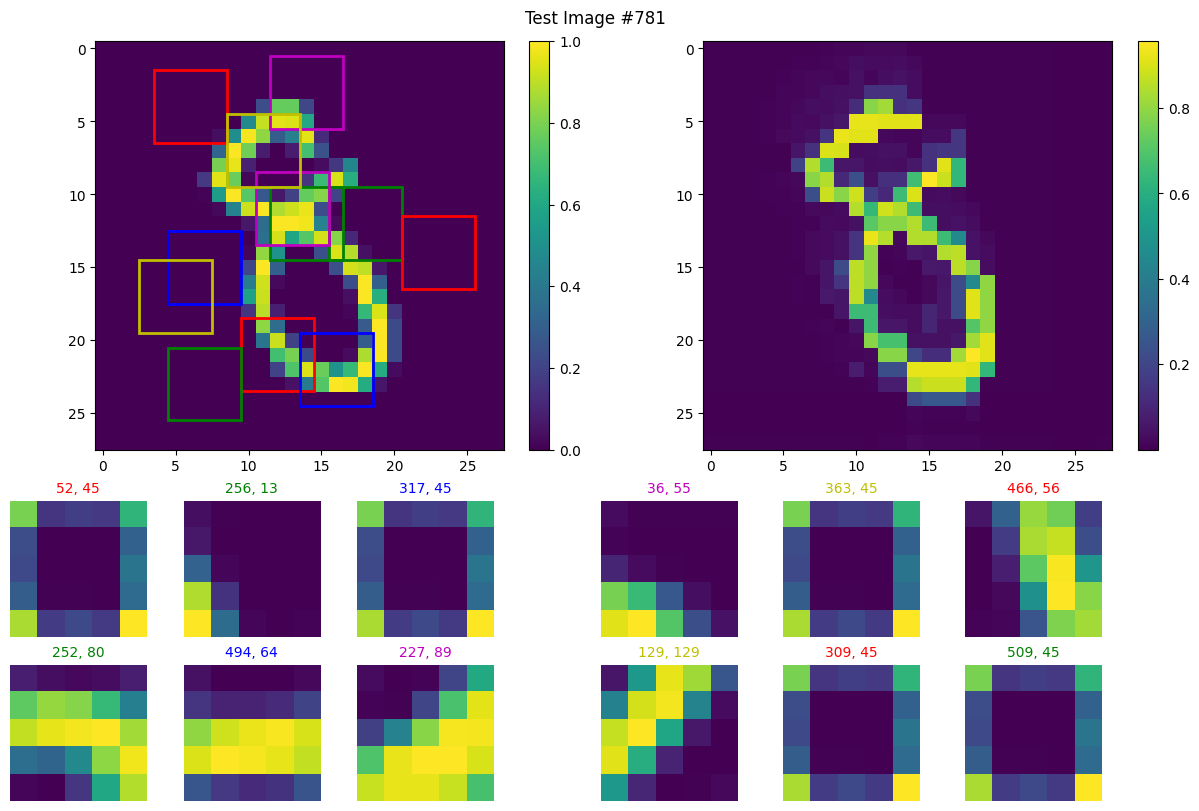

In [205]:
verify_samples(is_test=True)

## verify_p_matrix

In [306]:
def verify_p_matrix(is_test):
    with get_db_con(is_ro=True) as db_con:
        meta = load_meta(db_con)
        df_vocab_tokens = load_vocab_tokens(db_con)
        df_pos_tokens = load_pos_tokens(db_con)
        pos_ind_to_pos_token = dict(map(lambda t: (t.pos_ind, t), df_pos_tokens.itertuples()))
        vocab_token_ind_to_vocab_token = dict(map(lambda t: (t.Index, t), df_vocab_tokens.itertuples()))
        vocab_ind_to_vocab_token = dict(map(lambda t: (t.vocab_ind, t), df_vocab_tokens.itertuples()))
        
        table_name_prefix = ('', 'test_')[is_test]
        samples_table_name = table_name_prefix + 'noncausal_samples'
        df_image_inds = pd.read_sql(f'SELECT DISTINCT(image_ind) FROM {samples_table_name}', con=db_con)
        image_ind = int(RNG.choice(df_image_inds.image_ind))
        df_samples = pd.read_sql(f'SELECT sample, p_matrix, l_matrix ' + 
                                 f'FROM {samples_table_name} ' + 
                                 f'WHERE image_ind=?', params=[image_ind], con=db_con)
        sample = next(df_samples.itertuples()).sample
        l_matrix = next(df_samples.itertuples()).l_matrix
        l_matrix = np.load(BytesIO(l_matrix))
        p_matrix = next(df_samples.itertuples()).p_matrix
        p_matrix = np.load(BytesIO(p_matrix))
        sample = np.array(list(map(int, sample.split(','))))
        
        fig, axd = plt.subplot_mosaic(
            [
                ['A', 'A', 'A', 'B0', 'C0', 'D0', 'E0', 'F0'],
                ['A', 'A', 'A', 'B1', 'C1', 'D1', 'E1', 'F1'],
                ['A', 'A', 'A', 'B2', 'C2', 'D2', 'E2', 'F2'],
            ], 
            layout="constrained"
        )
        fig.set_figwidth(16)
        fig.set_figheight(3 * 2)
        image = load_image(db_con, image_ind, is_test)
        fig.suptitle(f'{LangUtils.when(is_test, "Test Image", "Image")} #{image_ind}')
        im = axd['A'].imshow(image)
        
        random_pos_inds = RNG.choice(len(sample), 5, replace=False)
        
        for ind, (pos_ind, ax_name) in enumerate(zip(random_pos_inds, 'BCDEF')):
            best_vocab_token_ind = sample[pos_ind]
            color = 'rgbmy'[ind % 5]
    
            pt = pos_ind_to_pos_token[pos_ind]
            rect = pltpatches.Rectangle((pt.j-0.5, pt.i-0.5), meta.patch_size, meta.patch_size, linewidth=2, edgecolor=color, facecolor='none')
            axd['A'].add_patch(rect)
            top = torch.topk(torch.tensor(p_matrix[pos_ind]), 3)
    
            for j, vocab_ind in zip(range(3), top.indices):
                vt = vocab_ind_to_vocab_token[vocab_ind.item()]
                
                if j == 0:
                    assert best_vocab_token_ind == vt.Index , f'{best_vocab_token_ind} != {vt.Index}'
                    
                with BytesIO(vt.data) as b: vocab_item = np.load(b)
                
                ax = axd[ax_name + str(j)]
                title = '\n'.join((
                    f'p={p_matrix[pos_ind,vocab_ind]*100:.0f}%, l={l_matrix[pos_ind,vocab_ind]:.2g} ({vt.Index})',
                ))
                ax.set_title(title, c=color, fontdict=dict(fontsize=10))
                ax.imshow(ArrayUtils.v2sm(vocab_item))
                ax.set_axis_off()

## Verify p_matrix train

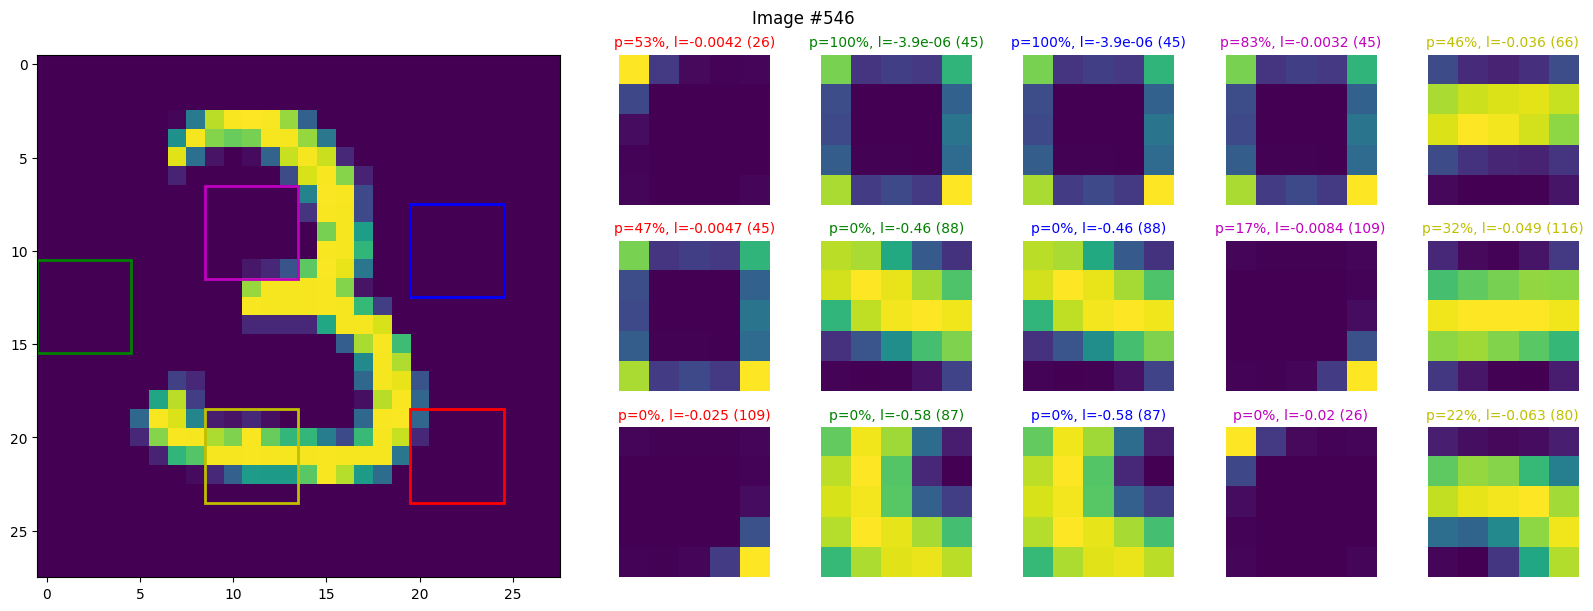

In [308]:
verify_p_matrix(is_test=False)

## Verify p_matrix test

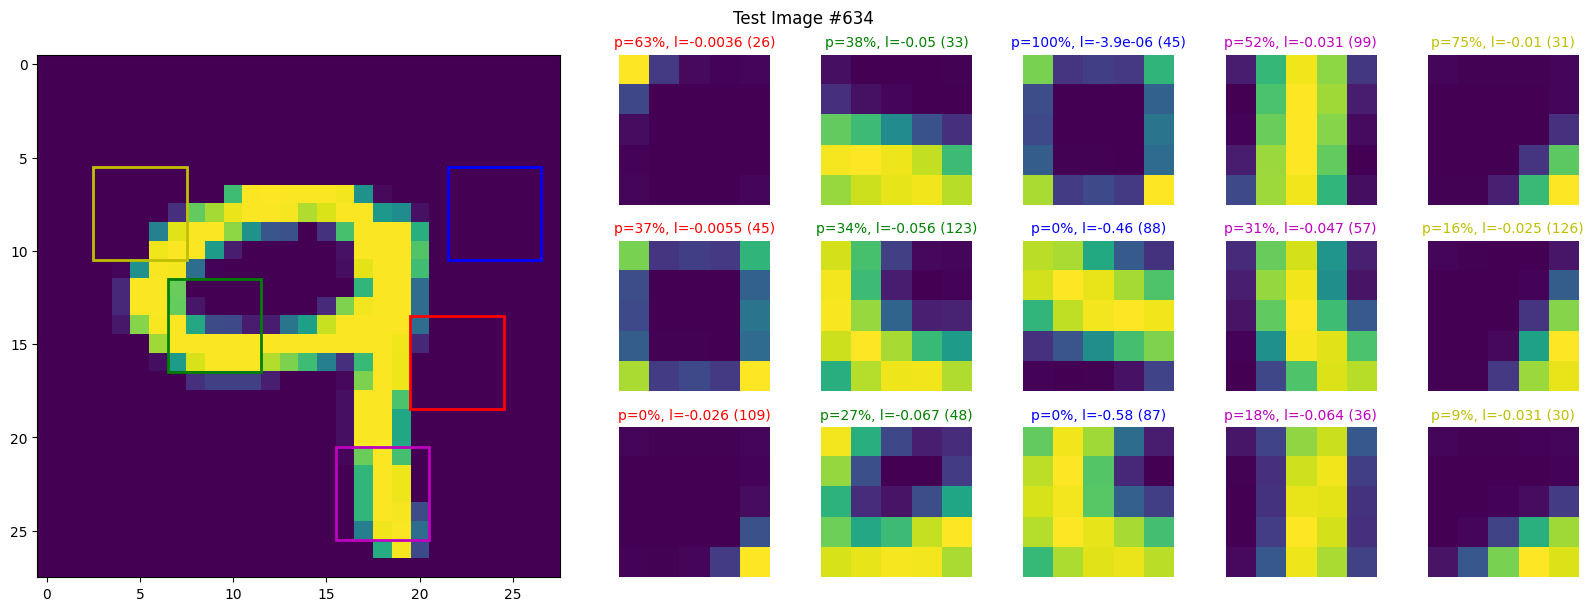

In [309]:
verify_p_matrix(is_test=True)

# LaunchIt!

In [8]:
# @launchit.disable
launchit_t0 = time.time()

In [18]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{CONFIG.model_group_uri}.{CONFIG.self_name}'))
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars)
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Creating /home/misha/dev/mine/neurovision/15_transformer/15_sample_01-launch14.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/15_transformer/15_sample_01-launch14.ipynb"
